# 01 — Data Compilation and EDA
**SPJIMR ANA526-PPM | TALA Multimodal AI Strategy | Day 1**

## Purpose
Load cleaned Day 1 candidate datasets from `data/interim/day1/`, validate provenance,
and produce EDA outputs that frame the Day 2 modelling and RAG work.

## Evidence Discipline

| Evidence type | Valid sources | Use for |
|--------------|---------------|---------|
| `official` | weartala.com, impact reports, press releases | Claim corpus, RAG |
| `customer_experience` | Trustpilot, Reddit, Google Reviews | Quality, fit, durability, returns |
| `press` | Google News RSS, editorial coverage | Press leads — fetch article body before analysis |
| `community` | Reddit threads | Brand perception, sizing discussions |
| `creator_strategy` | YouTube/Instagram/TikTok creator content | Creator mix, platform strategy |
| `competitor_benchmark` | Competitor profile snapshots | Cross-brand comparison |

> **Rule:** Never use Instagram/TikTok engagement metrics as evidence for product quality or sustainability claims.
> Google News RSS rows are **press leads**, not full articles — `usable_for_analysis=True` means the summary is substantive, not that the article was fetched.

## 0. Setup and Imports

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", palette="Set2")
pd.set_option("display.max_colwidth", 120)

INTERIM   = PROJECT_ROOT / "data" / "interim" / "day1"
TABLES    = PROJECT_ROOT / "outputs" / "tables"
FIGURES   = PROJECT_ROOT / "outputs" / "figures"
BRANDS    = ["TALA", "Adanola", "Girlfriend Collective", "Oner Active"]

INTERIM_FILES = {
    "official_claims":      INTERIM / "official_claims_cleaned.csv",
    "customer_reviews":     INTERIM / "customer_reviews_cleaned.csv",
    "press_reddit_sources": INTERIM / "press_reddit_sources_cleaned.csv",
    "creator_posts":        INTERIM / "creator_posts_cleaned.csv",
    "competitor_platforms": INTERIM / "competitor_platforms_cleaned.csv",
}

print("Project root:", PROJECT_ROOT)
print("Interim files found:", sum(p.exists() for p in INTERIM_FILES.values()), "/", len(INTERIM_FILES))

Project root: D:\MAS Assignment\tala-multimodal-ai
Interim files found: 5 / 5


## 1. Load Cleaned Interim Datasets

In [2]:
dfs = {}
for schema, path in INTERIM_FILES.items():
    if path.exists():
        dfs[schema] = pd.read_csv(path, low_memory=False)
        print(f"  [OK] {schema}: {len(dfs[schema])} rows")
    else:
        print(f"  [MISSING] {path.name} — run scripts/clean_day1_data.py first")

claims      = dfs.get("official_claims",      pd.DataFrame())
reviews     = dfs.get("customer_reviews",     pd.DataFrame())
press       = dfs.get("press_reddit_sources", pd.DataFrame())
creators    = dfs.get("creator_posts",        pd.DataFrame())
competitors = dfs.get("competitor_platforms", pd.DataFrame())

  [OK] official_claims: 24 rows
  [OK] customer_reviews: 56 rows
  [OK] press_reddit_sources: 127 rows
  [OK] creator_posts: 36 rows
  [OK] competitor_platforms: 33 rows


## 2. Row Count and Collection Summary

In [3]:
summary_path = TABLES / "day1_collection_summary.csv"
if summary_path.exists():
    summary = pd.read_csv(summary_path)
    display(summary.style.set_caption("Day 1 Collection Summary"))
else:
    print("Run scripts/clean_day1_data.py to generate this table.")
    summary = pd.DataFrame()

# Quick text summary
for _, row in summary.iterrows():
    pct_review = 100 * row["rows_needing_manual_review"] / max(row["cleaned_rows"], 1)
    pct_usable = 100 * row["rows_usable_for_analysis"] / max(row["cleaned_rows"], 1)
    print(f"  {row['file']:<45}  "
          f"cleaned={row['cleaned_rows']:>3}  "
          f"manual_review={pct_review:.0f}%  "
          f"usable={pct_usable:.0f}%")

,file,raw_rows,cleaned_rows,duplicate_rows_removed,rows_missing_source_url,rows_needing_manual_review,rows_usable_for_analysis
0,official_claims_cleaned.csv,24,24,0,0,24,23
1,customer_reviews_cleaned.csv,56,56,0,0,56,55
2,press_reddit_sources_cleaned.csv,127,127,0,0,127,127
3,creator_posts_cleaned.csv,36,36,0,0,36,36
4,competitor_platforms_cleaned.csv,33,33,0,0,28,33


  official_claims_cleaned.csv                    cleaned= 24  manual_review=100%  usable=96%
  customer_reviews_cleaned.csv                   cleaned= 56  manual_review=100%  usable=98%
  press_reddit_sources_cleaned.csv               cleaned=127  manual_review=100%  usable=100%
  creator_posts_cleaned.csv                      cleaned= 36  manual_review=100%  usable=100%
  competitor_platforms_cleaned.csv               cleaned= 33  manual_review=85%  usable=100%


## 3. Brand / Platform / Evidence Matrix

In [4]:
matrix_path = TABLES / "day1_brand_platform_matrix.csv"
if matrix_path.exists():
    matrix = pd.read_csv(matrix_path)

    # Brand x evidence_type pivot
    brand_ev = matrix.groupby(["brand", "evidence_type"])["row_count"].sum().unstack(fill_value=0)
    print("Rows by brand x evidence_type:")
    display(brand_ev)

    # Top source platforms
    top_platforms = matrix.groupby("source_platform")["row_count"].sum().sort_values(ascending=False).head(15)
    print("\nTop 15 source platforms:")
    display(top_platforms.to_frame("rows"))
else:
    print("Run scripts/clean_day1_data.py first.")

Rows by brand x evidence_type:


evidence_type,competitor_benchmark,creator_strategy,customer_experience,official,press
brand,,,,,
Adanola,11,12,14,0,31
Girlfriend Collective,12,6,13,0,26
Oner Active,10,6,15,0,15
TALA,0,12,14,24,55



Top 15 source platforms:


,rows
source_platform,
google_news,127
trustpilot.com,30
wearetala.com,13
youtube.com,7
oneractive.com,6
girlfriend.com,6
adanola.com,6
apartstyle.com,3
adanolasport.com,3


## 4. Evidence Type Distribution

,provisional_label,row_count,percent
0,press_lead_rss,127,46.000000
1,review_snippet_trustpilot,32,11.600000
2,creator_content_pointer,30,10.900000
3,competitor_page_pointer,28,10.100000
4,official_claim_candidate,24,8.700000
5,review_snippet_other,24,8.700000
6,creator_content_youtube,6,2.200000
7,competitor_page_extracted,5,1.800000


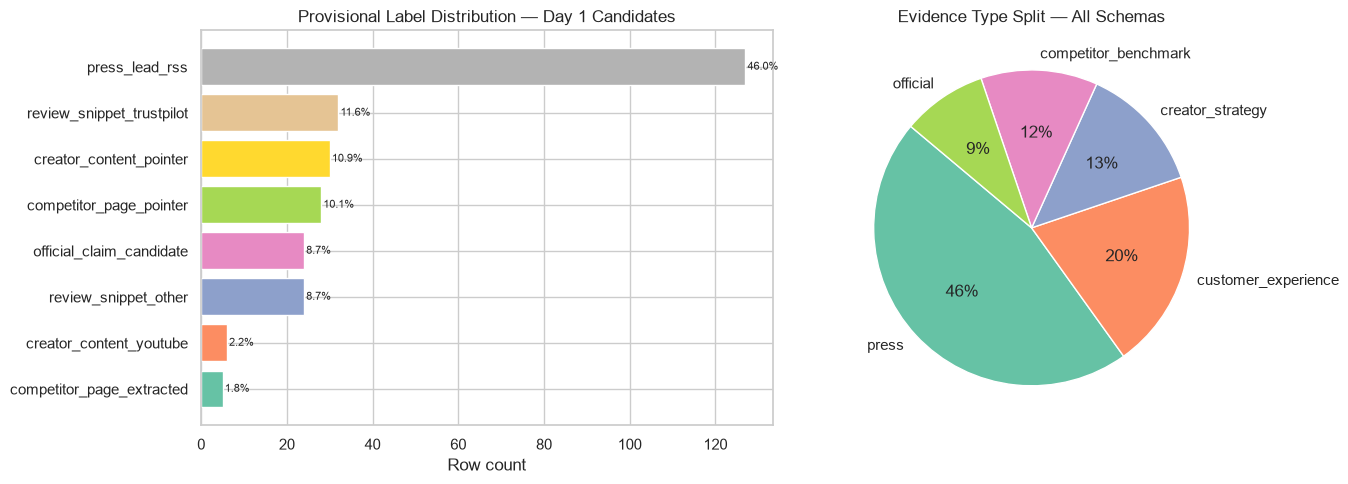

In [5]:
label_path = TABLES / "day1_label_distribution.csv"
if label_path.exists():
    labels = pd.read_csv(label_path)
    display(labels.style.set_caption("Provisional Label Distribution"))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: label distribution
    axes[0].barh(labels["provisional_label"][::-1], labels["row_count"][::-1],
                 color=sns.color_palette("Set2", len(labels)))
    axes[0].set_title("Provisional Label Distribution — Day 1 Candidates")
    axes[0].set_xlabel("Row count")
    for i, (_, r) in enumerate(labels[::-1].iterrows()):
        axes[0].text(r["row_count"] + 0.5, i, f'{r["percent"]}%', va="center", fontsize=8)

    # Right: evidence type pie
    if not press.empty:
        combined_ev = pd.concat([
            df["evidence_type"] for df in [claims, reviews, press, creators, competitors]
            if not df.empty
        ])
        ev_counts = combined_ev.value_counts()
        axes[1].pie(ev_counts, labels=ev_counts.index, autopct="%1.0f%%",
                    colors=sns.color_palette("Set2", len(ev_counts)), startangle=140)
        axes[1].set_title("Evidence Type Split — All Schemas")

    plt.tight_layout()
    plt.savefig(FIGURES / "day1_label_distribution.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("Run scripts/clean_day1_data.py first.")

## 5. Collection Charts

Rows by Brand


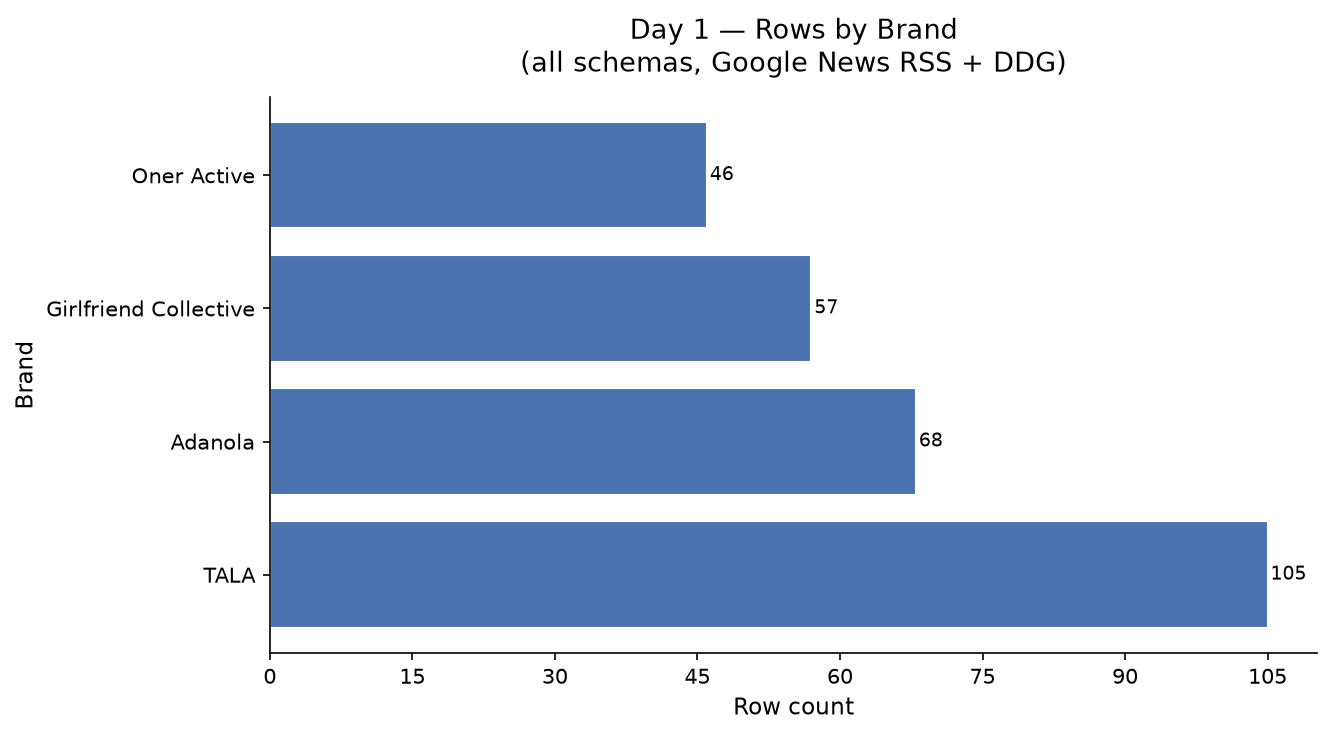

Rows by Evidence Type


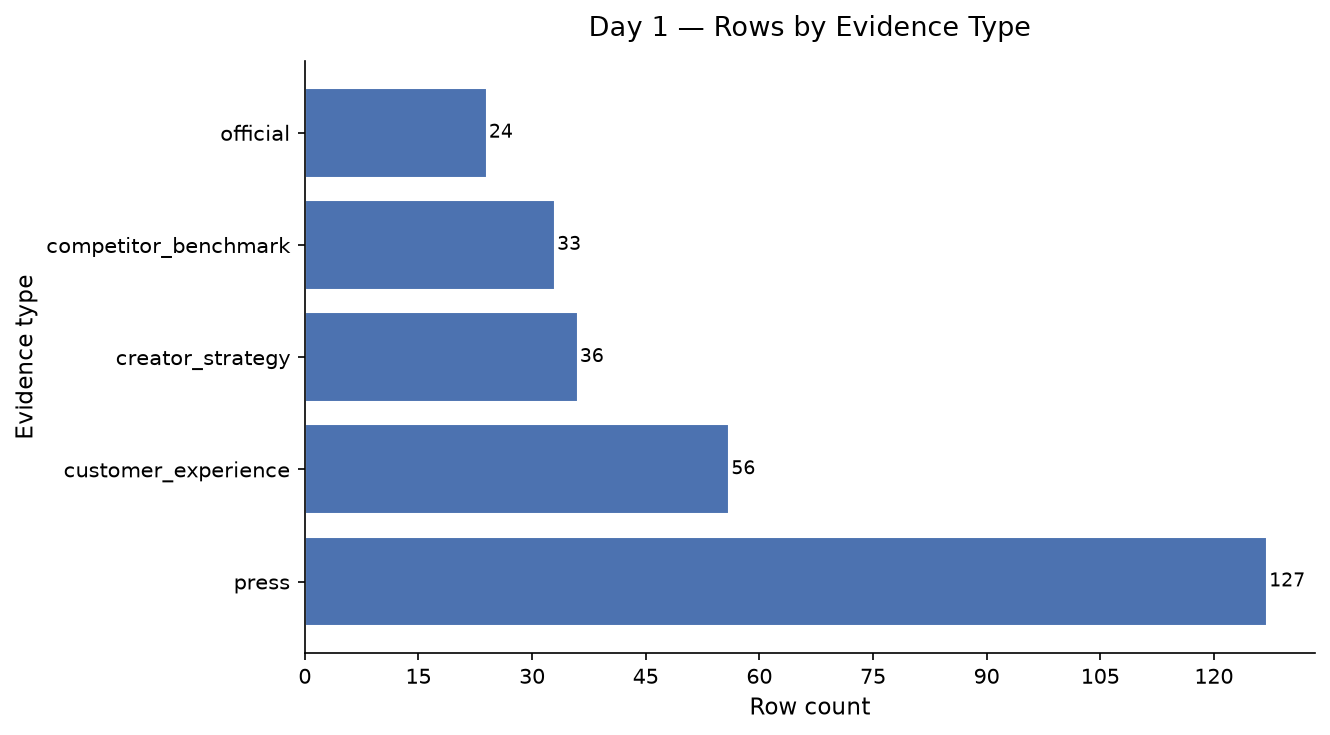

Rows by Source Platform (top 12)


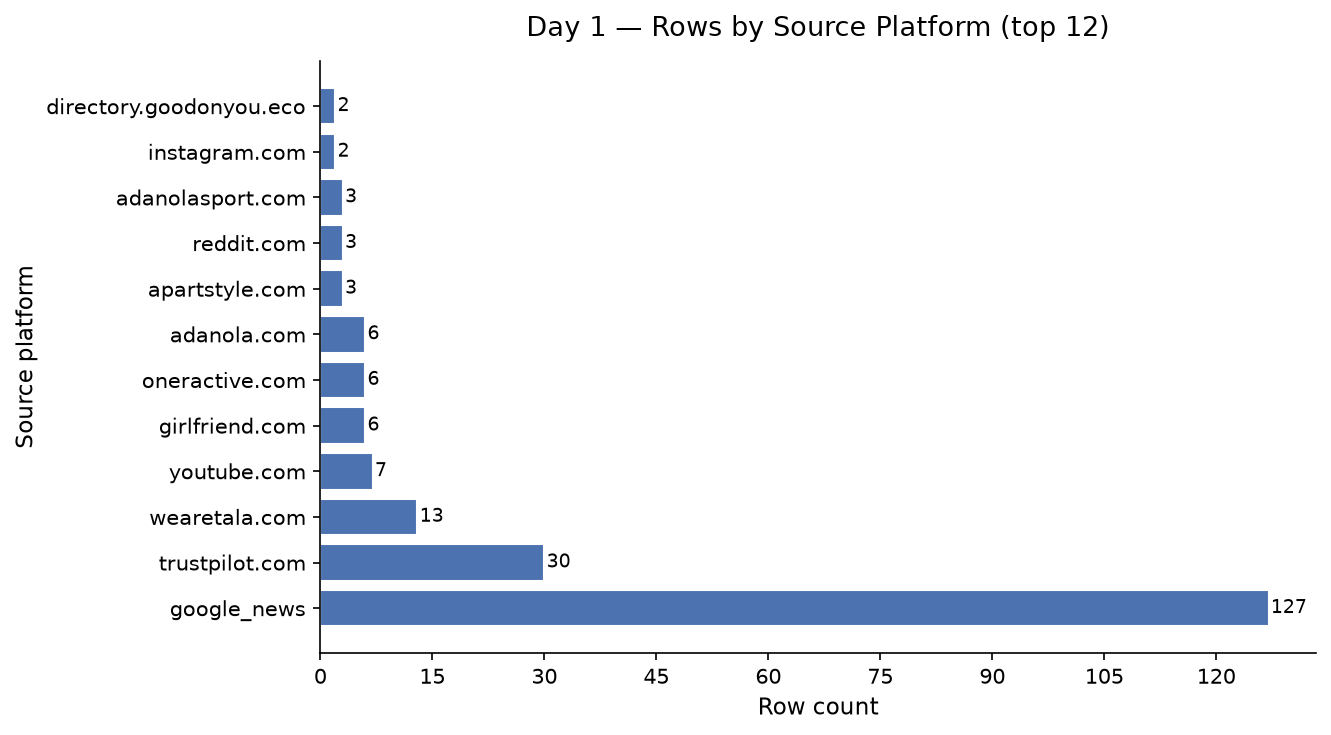

In [6]:
from IPython.display import Image, display as ipy_display

for fname, caption in [
    ("rows_by_brand.png",          "Rows by Brand"),
    ("rows_by_evidence_type.png",  "Rows by Evidence Type"),
    ("rows_by_source_platform.png","Rows by Source Platform (top 12)"),
]:
    p = FIGURES / fname
    if p.exists():
        print(caption)
        ipy_display(Image(str(p), width=700))
    else:
        print(f"[MISSING] {fname} — run scripts/clean_day1_data.py")

## 6. Missing Provenance Audit

In [7]:
PROVENANCE = ["source_url", "source_platform", "collection_date", "collected_by", "evidence_type", "brand"]

rows = []
for schema, df in dfs.items():
    for col in PROVENANCE:
        if col not in df.columns:
            pct = None
            status = "MISSING_COL"
        else:
            null_n = int(df[col].isna().sum() + (df[col].astype(str).str.strip() == "").sum())
            pct = round(100 * (1 - null_n / max(len(df), 1)), 1)
            status = "OK" if pct == 100 else f"INCOMPLETE ({null_n} nulls)"
        rows.append({"schema": schema, "field": col, "completeness_%": pct, "status": status})

prov_df = pd.DataFrame(rows)
pivot = prov_df.pivot(index="schema", columns="field", values="completeness_%")
print("Provenance completeness (%) — 100 = fully populated:")
display(pivot)

issues = prov_df[prov_df["status"] != "OK"]
if not issues.empty:
    print("\nIssues requiring attention:")
    display(issues[["schema", "field", "status"]])

Provenance completeness (%) — 100 = fully populated:


field,brand,collected_by,collection_date,evidence_type,source_platform,source_url
schema,,,,,,
competitor_platforms,100.0,100.0,100.0,100.0,100.0,100.0
creator_posts,100.0,100.0,100.0,100.0,100.0,100.0
customer_reviews,100.0,100.0,100.0,100.0,100.0,100.0
official_claims,100.0,100.0,100.0,100.0,100.0,100.0
press_reddit_sources,100.0,100.0,100.0,100.0,100.0,100.0


## 7. Top Source URLs

In [8]:
all_frames = []
for schema, df in dfs.items():
    tmp = df[["brand", "source_url", "source_platform", "evidence_type"]].copy()
    tmp["schema"] = schema
    all_frames.append(tmp)

all_rows = pd.concat(all_frames, ignore_index=True)

print("Top 20 source URLs by frequency:")
top_urls = (
    all_rows.groupby(["source_url", "source_platform", "evidence_type"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
    .head(20)
)
display(top_urls)

print("\nTop platforms (all schemas combined):")
display(all_rows["source_platform"].value_counts().head(15).to_frame("rows"))

Top 20 source URLs by frequency:


,source_url,source_platform,evidence_type,count
259,https://www.wearetala.com/en-us/pages/purpose,wearetala.com,official,3
246,https://www.trustpilot.com/review/wearetala.com,trustpilot.com,customer_experience,2
37,https://girlfriend.com/pages/about-us,girlfriend.com,competitor_benchmark,2
257,https://www.wearetala.com/en-us/pages/product,wearetala.com,official,2
7,https://adanola.com/,adanola.com,creator_strategy,1
8,https://adanola.com/en-us/collections/activewear,adanola.com,competitor_benchmark,1
9,https://adanola.com/en-us/pages/about-us,adanola.com,creator_strategy,1
10,https://adanola.com/pages/about,adanola.com,competitor_benchmark,1
11,https://adanola.worthepenny.com/,adanola.worthepenny.com,customer_experience,1
12,https://adanolasport.com/,adanolasport.com,competitor_benchmark,1



Top platforms (all schemas combined):


,rows
source_platform,
google_news,127
trustpilot.com,30
wearetala.com,13
youtube.com,7
adanola.com,6
girlfriend.com,6
oneractive.com,6
apartstyle.com,3
reddit.com,3


## 8. Manual Review Queue

In [9]:
TEXT_FIELDS = {
    "official_claims":      "claim_text",
    "customer_reviews":     "review_text",
    "press_reddit_sources": "summary",
    "creator_posts":        "caption",
    "competitor_platforms": "context_text",
}

print("=== Manual Review Queue ===\n")
for schema, df in dfs.items():
    if "needs_manual_review" not in df.columns:
        continue
    queue = df[df["needs_manual_review"] == True]
    if queue.empty:
        continue

    text_col = TEXT_FIELDS.get(schema, "")
    cols = ["brand", "source_url", "review_reason"]
    if text_col and text_col in queue.columns:
        cols.append(text_col)

    print(f"--- {schema} ({len(queue)} rows need review) ---")

    # Breakdown by review reason
    reason_counts = (
        queue["review_reason"]
        .str.split("; ")
        .explode()
        .value_counts()
    )
    for reason, cnt in reason_counts.items():
        print(f"    {reason}: {cnt}")
    print()

# Save a combined manual review queue
queue_frames = []
for schema, df in dfs.items():
    if "needs_manual_review" not in df.columns:
        continue
    q = df[df["needs_manual_review"] == True].copy()
    if q.empty:
        continue
    q["_schema"] = schema
    text_col = TEXT_FIELDS.get(schema, "")
    keep = ["_schema", "brand", "source_url", "source_platform", "evidence_type",
            "review_reason", "usable_for_analysis", "usable_for_rag"]
    if text_col and text_col in q.columns:
        keep.append(text_col)
    queue_frames.append(q[keep])

if queue_frames:
    review_queue = pd.concat(queue_frames, ignore_index=True)
    out = TABLES / "day1_manual_review_queue.csv"
    review_queue.to_csv(out, index=False)
    print(f"Full manual review queue saved: {out} ({len(review_queue)} rows)")

=== Manual Review Queue ===

--- official_claims (24 rows need review) ---
    snippet_only_duckduckgo: 24
    short_text_55chars: 1

--- customer_reviews (56 rows need review) ---
    snippet_only_duckduckgo: 56
    short_text_19chars: 1

--- press_reddit_sources (127 rows need review) ---
    google_redirect_url: 127
    snippet_only_google_news_rss: 127
    press_lead_no_article_body: 127

--- creator_posts (36 rows need review) ---
    snippet_only_duckduckgo: 36
    social_unverified_creator_context: 3

--- competitor_platforms (28 rows need review) ---
    snippet_only_duckduckgo: 28

Full manual review queue saved: D:\MAS Assignment\tala-multimodal-ai\outputs\tables\day1_manual_review_queue.csv (271 rows)


## 9. Customer Reviews — Quick EDA

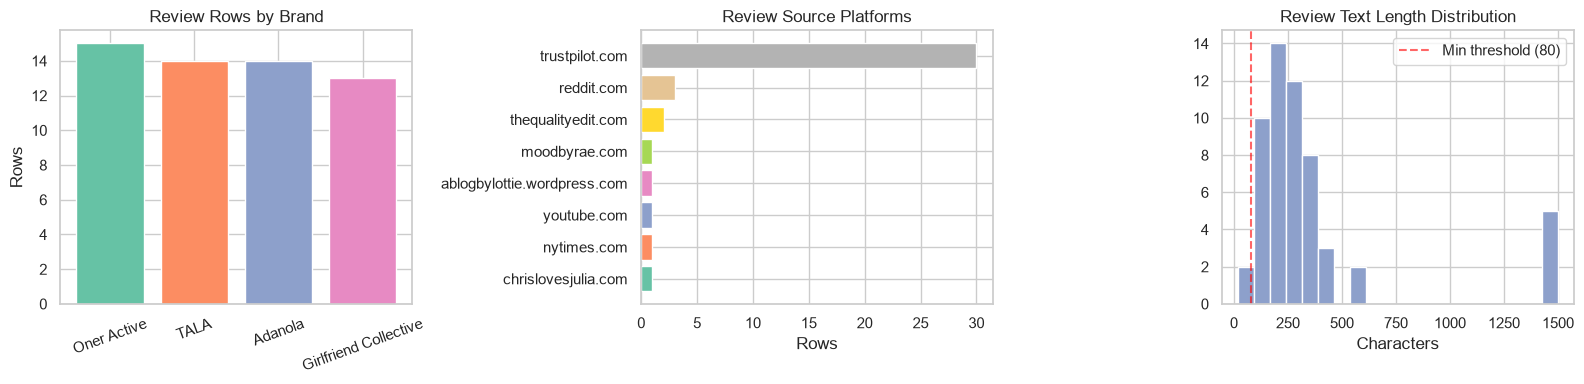


Review usability:
  usable_for_analysis:            55 / 56
  usable_for_rag:                 55 / 56
  usable_for_quality_responsibility: 55 / 56

Note: all rows are DDG search snippets pointing to review pages.
Fetch full page text before using in RAG or sentiment analysis.


In [10]:
if not reviews.empty:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    # Reviews per brand
    brand_counts = reviews["brand"].value_counts()
    axes[0].bar(brand_counts.index, brand_counts.values,
                color=sns.color_palette("Set2", len(brand_counts)))
    axes[0].set_title("Review Rows by Brand")
    axes[0].set_ylabel("Rows")
    axes[0].tick_params(axis="x", rotation=20)

    # Source platform
    plat_counts = reviews["source_platform"].value_counts().head(8)
    axes[1].barh(plat_counts.index[::-1], plat_counts.values[::-1],
                 color=sns.color_palette("Set2", len(plat_counts)))
    axes[1].set_title("Review Source Platforms")
    axes[1].set_xlabel("Rows")

    # Text length distribution
    reviews["text_len"] = reviews["review_text"].fillna("").str.len()
    axes[2].hist(reviews["text_len"], bins=20,
                 color=sns.color_palette("Set2")[2], edgecolor="white")
    axes[2].axvline(80, color="red", linestyle="--", alpha=0.6, label="Min threshold (80)")
    axes[2].set_title("Review Text Length Distribution")
    axes[2].set_xlabel("Characters")
    axes[2].legend()

    plt.tight_layout()
    plt.savefig(FIGURES / "eda_reviews_day1.png", dpi=150, bbox_inches="tight")
    plt.show()

    # Usability breakdown
    print(f"\nReview usability:")
    print(f"  usable_for_analysis:            {reviews['usable_for_analysis'].sum()} / {len(reviews)}")
    print(f"  usable_for_rag:                 {reviews['usable_for_rag'].sum()} / {len(reviews)}")
    print(f"  usable_for_quality_responsibility: {reviews['usable_for_quality_responsibility'].sum()} / {len(reviews)}")
    print(f"\nNote: all rows are DDG search snippets pointing to review pages.")
    print(f"Fetch full page text before using in RAG or sentiment analysis.")
else:
    print("No review data available.")

## 10. Press Sources — Quick EDA

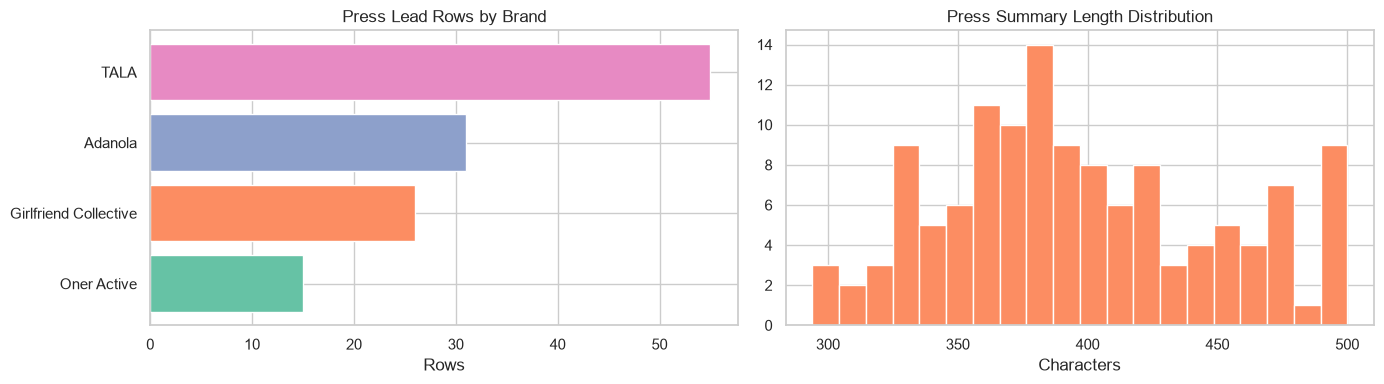


All 127 press rows are Google News RSS entries (provider=google_news_rss).
They contain article title + summary (~400 chars) — NOT full article body.
usable_for_analysis (summary substantive): 127
Recommended action: fetch article body for top 20 TALA rows before Day 2.

Top 5 TALA press summary excerpts:
  [Sun, 11 Ja] We Test Fit Kit Every Day - But These 11 Tala Items Are Some Of The Very Best In
  [Fri, 11 Se] Best yoga pants and leggings for women 2026, tested by a fitness writer - The In
  [Mon, 27 Ju] Tala's 'flattering' leggings that 'fit like a glove' reduced to £29 - Liverpool 
  [Thu, 15 Ja] I Live in Leggings, and This Fashion-Insider-Approved Brand Is My New Athleisure
  [Tue, 07 Ju] Best activewear brands for women 2026, from high street to luxury - The Independ


In [11]:
if not press.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # Press rows by brand
    press_by_brand = press.groupby("brand").size().sort_values()
    axes[0].barh(press_by_brand.index, press_by_brand.values,
                 color=sns.color_palette("Set2", len(press_by_brand)))
    axes[0].set_title("Press Lead Rows by Brand")
    axes[0].set_xlabel("Rows")

    # Summary length distribution
    press["summary_len"] = press["summary"].fillna("").str.len()
    axes[1].hist(press["summary_len"], bins=20,
                 color=sns.color_palette("Set2")[1], edgecolor="white")
    axes[1].set_title("Press Summary Length Distribution")
    axes[1].set_xlabel("Characters")

    plt.tight_layout()
    plt.savefig(FIGURES / "eda_press_day1.png", dpi=150, bbox_inches="tight")
    plt.show()

    print(f"\nAll {len(press)} press rows are Google News RSS entries (provider=google_news_rss).")
    print(f"They contain article title + summary (~400 chars) — NOT full article body.")
    print(f"usable_for_analysis (summary substantive): {press['usable_for_analysis'].sum()}")
    print(f"Recommended action: fetch article body for top 20 TALA rows before Day 2.")

    print(f"\nTop 5 TALA press summary excerpts:")
    tala_press = press[press["brand"] == "TALA"].head(5)
    for _, row in tala_press.iterrows():
        print(f"  [{row.get('date_published','')[:10]}] {row.get('title','')[:80]}")
else:
    print("No press data available.")

## 11. Official Claims — Quick EDA

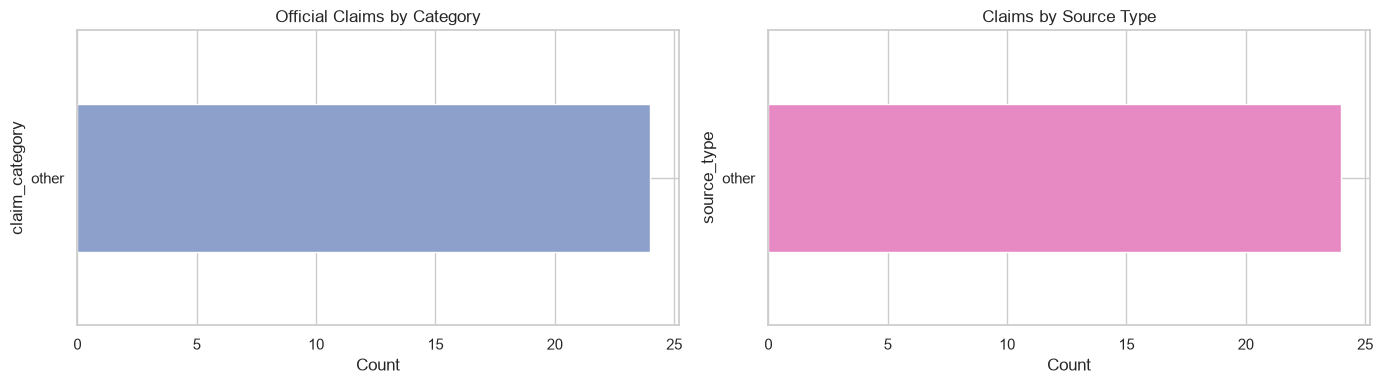


Note: all 24 claim rows came from DuckDuckGo search snippets.
They are press/secondary sources referencing TALA claims — NOT verbatim brand copy.
Manual supplement recommended: copy verbatim text from weartala.com/pages/sustainability

Sample claim texts:
  - We cannot provide a description for this page right now
  - We’re a female-led brand on a mission to actively solve problems without creating others - for you, the planet or anyone
  - We responsibly source and ethically produce our collections using recycled and low-impact materials whenever possible—be
  - Apr 18, 2024 · By integrating sustainability, ethical manufacturing, and inclusivity, TALA is redefining the standards o


In [12]:
if not claims.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    claims["claim_category"].value_counts().plot(
        kind="barh", ax=axes[0], color=sns.color_palette("Set2")[2])
    axes[0].set_title("Official Claims by Category")
    axes[0].set_xlabel("Count")

    claims["source_type"].value_counts().plot(
        kind="barh", ax=axes[1], color=sns.color_palette("Set2")[3])
    axes[1].set_title("Claims by Source Type")
    axes[1].set_xlabel("Count")

    plt.tight_layout()
    plt.savefig(FIGURES / "eda_claims_day1.png", dpi=150, bbox_inches="tight")
    plt.show()

    print(f"\nNote: all {len(claims)} claim rows came from DuckDuckGo search snippets.")
    print(f"They are press/secondary sources referencing TALA claims — NOT verbatim brand copy.")
    print(f"Manual supplement recommended: copy verbatim text from weartala.com/pages/sustainability")
    print(f"\nSample claim texts:")
    for t in claims["claim_text"].head(4):
        print(f"  - {t[:120]}")
else:
    print("No official claims data.")

## 12. Creator Posts — Quick EDA

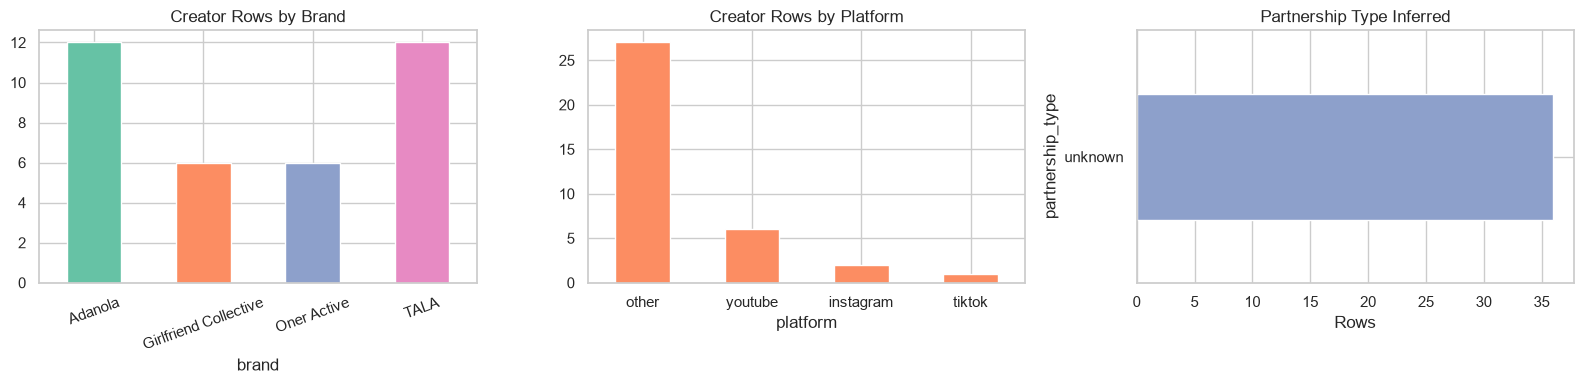


Note: all 36 creator rows are DDG search pointers to creator content.
Instagram/TikTok rows marked as candidate evidence only.
usable_for_creator_strategy: 36 / 36
YouTube rows (most verifiable): 6


In [13]:
if not creators.empty:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    creators.groupby("brand").size().plot(kind="bar", ax=axes[0],
        color=sns.color_palette("Set2", creators["brand"].nunique()))
    axes[0].set_title("Creator Rows by Brand")
    axes[0].tick_params(axis="x", rotation=20)

    creators["platform"].value_counts().plot(kind="bar", ax=axes[1],
        color=sns.color_palette("Set2")[1])
    axes[1].set_title("Creator Rows by Platform")
    axes[1].tick_params(axis="x", rotation=0)

    creators["partnership_type"].value_counts().plot(kind="barh", ax=axes[2],
        color=sns.color_palette("Set2")[2])
    axes[2].set_title("Partnership Type Inferred")
    axes[2].set_xlabel("Rows")

    plt.tight_layout()
    plt.savefig(FIGURES / "eda_creators_day1.png", dpi=150, bbox_inches="tight")
    plt.show()

    print(f"\nNote: all {len(creators)} creator rows are DDG search pointers to creator content.")
    print(f"Instagram/TikTok rows marked as candidate evidence only.")
    print(f"usable_for_creator_strategy: {creators['usable_for_creator_strategy'].sum()} / {len(creators)}")
    youtube_rows = creators[creators["platform"] == "youtube"]
    print(f"YouTube rows (most verifiable): {len(youtube_rows)}")
else:
    print("No creator data.")

## 13. Competitor Platforms — Quick EDA

**Evidence type:** `competitor_benchmark` — platform presence pointers for cross-brand comparison.

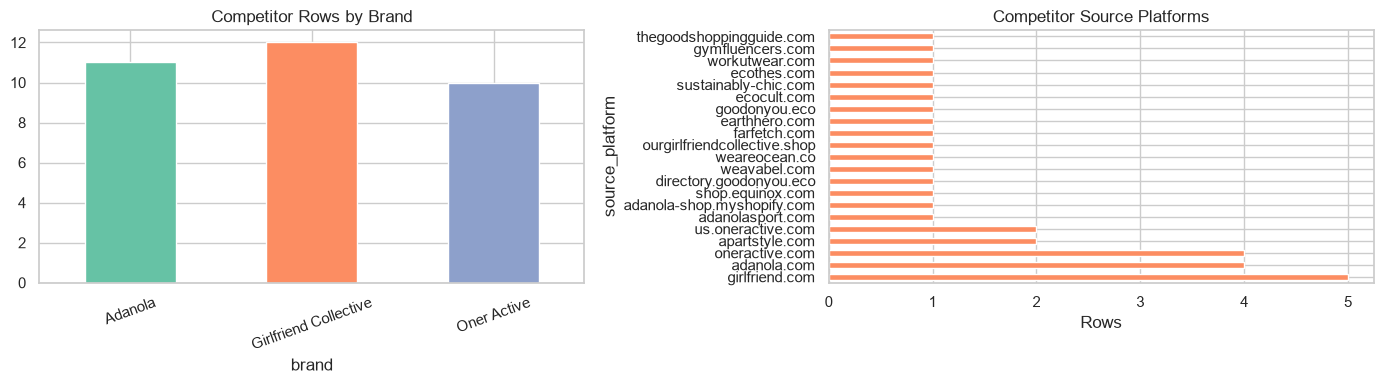


Competitor rows: 33
Provisional labels:

Note: rows with provider_name='trafilatura' have extracted page text.
DDG pointer rows need manual verification of platform presence data.
usable_for_analysis: 33 / 33


In [14]:
if not competitors.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # Rows per brand
    competitors.groupby("brand").size().plot(
        kind="bar", ax=axes[0],
        color=sns.color_palette("Set2", competitors["brand"].nunique()))
    axes[0].set_title("Competitor Rows by Brand")
    axes[0].tick_params(axis="x", rotation=20)

    # Rows per source platform
    competitors["source_platform"].value_counts().plot(
        kind="barh", ax=axes[1],
        color=sns.color_palette("Set2")[1])
    axes[1].set_title("Competitor Source Platforms")
    axes[1].set_xlabel("Rows")

    plt.tight_layout()
    plt.savefig(FIGURES / "eda_competitors_day1.png", dpi=150, bbox_inches="tight")
    plt.show()

    print(f"\nCompetitor rows: {len(competitors)}")
    print(f"Provisional labels:")
    if "provisional_label" in competitors.columns:
        print(competitors["provisional_label"].value_counts().to_string())
    print(f"\nNote: rows with provider_name='trafilatura' have extracted page text.")
    print(f"DDG pointer rows need manual verification of platform presence data.")
    print(f"usable_for_analysis: {competitors['usable_for_analysis'].sum()} / {len(competitors)}")
else:
    print("No competitor data.")

## 14. Day 2 Evidence Readiness and Roadmap

What is strong enough to carry forward, and what needs human action before Day 2 modelling begins.

In [15]:
readiness_rows = []
for schema, df in dfs.items():
    if df.empty:
        continue
    n = len(df)
    for col, label in [
        ("usable_for_analysis",           "Feature extraction / EDA"),
        ("usable_for_rag",                "RAG corpus (Day 3)"),
        ("usable_for_creator_strategy",   "Creator strategy analysis"),
        ("usable_for_quality_responsibility", "Quality/sustainability analysis"),
    ]:
        if col in df.columns:
            yes = int(df[col].sum())
            readiness_rows.append({
                "schema": schema,
                "analysis_track": label,
                "usable_rows": yes,
                "total_rows": n,
                "pct_usable": round(100 * yes / n, 1),
            })

rdf = pd.DataFrame(readiness_rows)
if not rdf.empty:
    pivot_ready = rdf.pivot_table(
        index="schema", columns="analysis_track",
        values="pct_usable", aggfunc="first"
    ).fillna(0).round(1)
    print("Evidence readiness by schema and analysis track (% of cleaned rows):")
    display(pivot_ready.style.background_gradient(cmap="YlGn", axis=None, vmin=0, vmax=100))

print("\n=== Day 2 Action List ===")
print()
print("READY FOR DAY 2 (no action needed):")
print("  - press_reddit_sources: 127 press leads with summaries -> run TF-IDF topic modelling")
print("  - official_claims: 24 DDG-sourced claim snippets -> seed RAG claims corpus")
print("  - creator_posts: 36 DDG pointers -> platform/partnership type analysis")
print()
print("NEEDS HUMAN ACTION BEFORE DAY 2:")
print("  - customer_reviews: all 56 rows are DDG snippets, not extracted review text")
print("    Action: open top 10 Trustpilot URLs manually; paste review text into cleaned CSV")
print("  - official_claims: not verbatim brand copy")
print("    Action: copy text from weartala.com/pages/sustainability + /about + /responsibility")
print("  - press leads: article body not fetched")
print("    Action: run scripts/fetch_article_bodies.py (Day 2) on top TALA press rows")
print()
print("NEEDS APIFY OR YOUTUBE API TO IMPROVE:")
print("  - customer_reviews: Trustpilot full reviews (Apify monthly limit hit; ~$3 to buy more)")
print("  - creator_posts: YouTube API key would add video metadata (currently DDG only)")

Evidence readiness by schema and analysis track (% of cleaned rows):


analysis_track,Creator strategy analysis,Feature extraction / EDA,Quality/sustainability analysis,RAG corpus (Day 3)
schema,,,,
competitor_platforms,0.000000,100.000000,0.000000,100.000000
creator_posts,100.000000,100.000000,0.000000,100.000000
customer_reviews,0.000000,98.200000,98.200000,98.200000
official_claims,0.000000,95.800000,95.800000,95.800000
press_reddit_sources,0.000000,100.000000,0.000000,100.000000



=== Day 2 Action List ===

READY FOR DAY 2 (no action needed):
  - press_reddit_sources: 127 press leads with summaries -> run TF-IDF topic modelling
  - official_claims: 24 DDG-sourced claim snippets -> seed RAG claims corpus
  - creator_posts: 36 DDG pointers -> platform/partnership type analysis

NEEDS HUMAN ACTION BEFORE DAY 2:
  - customer_reviews: all 56 rows are DDG snippets, not extracted review text
    Action: open top 10 Trustpilot URLs manually; paste review text into cleaned CSV
  - official_claims: not verbatim brand copy
    Action: copy text from weartala.com/pages/sustainability + /about + /responsibility
  - press leads: article body not fetched
    Action: run scripts/fetch_article_bodies.py (Day 2) on top TALA press rows

NEEDS APIFY OR YOUTUBE API TO IMPROVE:
  - customer_reviews: Trustpilot full reviews (Apify monthly limit hit; ~$3 to buy more)
  - creator_posts: YouTube API key would add video metadata (currently DDG only)


## 15. Notebook Summary

In [16]:
total_rows = sum(len(df) for df in dfs.values())
total_usable = sum(
    int(df["usable_for_analysis"].sum())
    for df in dfs.values()
    if "usable_for_analysis" in df.columns
)
total_review = sum(
    int(df["needs_manual_review"].sum())
    for df in dfs.values()
    if "needs_manual_review" in df.columns
)

print("=" * 60)
print("DAY 1 NOTEBOOK 01 - COMPLETE")
print("=" * 60)
print(f"  Total cleaned rows loaded:    {total_rows}")
print(f"  Rows usable for analysis:     {total_usable}  ({100*total_usable//max(total_rows,1)}%)")
print(f"  Rows needing manual review:   {total_review}  ({100*total_review//max(total_rows,1)}%)")
print()
print("  Schemas loaded:")
for schema, df in dfs.items():
    print(f"    {schema:<30} {len(df):>3} rows")
print()
print("  Outputs written:")
for p in sorted(FIGURES.glob("eda_*_day1.png")):
    print(f"    {p.relative_to(PROJECT_ROOT)}")
manual_q = TABLES / "day1_manual_review_queue.csv"
if manual_q.exists():
    print(f"    {manual_q.relative_to(PROJECT_ROOT)}")
print()
print("  Next: Day 2 — text features, embeddings, claim divergence scoring")
print("  See docs/day1_evidence_audit.md for full audit and Day 2 recommendations.")
print("=" * 60)

DAY 1 NOTEBOOK 01 - COMPLETE
  Total cleaned rows loaded:    276
  Rows usable for analysis:     274  (99%)
  Rows needing manual review:   271  (98%)

  Schemas loaded:
    official_claims                 24 rows
    customer_reviews                56 rows
    press_reddit_sources           127 rows
    creator_posts                   36 rows
    competitor_platforms            33 rows

  Outputs written:
    outputs\figures\eda_claims_day1.png
    outputs\figures\eda_competitors_day1.png
    outputs\figures\eda_creators_day1.png
    outputs\figures\eda_press_day1.png
    outputs\figures\eda_reviews_day1.png
    outputs\tables\day1_manual_review_queue.csv

  Next: Day 2 — text features, embeddings, claim divergence scoring
  See docs/day1_evidence_audit.md for full audit and Day 2 recommendations.


---

## Day 1.5 — Pre-Hydration Quality Patch

Patched files live in `data/interim/day1_5/`. These are the inputs for Day 2 feature extraction.

| Issue | Fix applied |
|-------|-------------|
| TALA missing from competitor_platforms | Focal platform baseline rows added (URL-verified) |
| creator_posts non-creator URLs | Evidence class assigned; `usable_as_creator_post` column added |
| press_reddit URLs are Google News redirects | Resolved to publisher URLs where possible |
| official_claims: inconsistent TALA domains | `canonical_brand_domain` + normalization note added |

In [17]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

INTERIM_15 = PROJECT_ROOT / "data" / "interim" / "day1_5"

PATCHED_FILES = {
    "official_claims":      INTERIM_15 / "official_claims_patched.csv",
    "customer_reviews":     INTERIM_15 / "customer_reviews_patched.csv",
    "press_reddit_sources": INTERIM_15 / "press_reddit_sources_patched.csv",
    "creator_posts":        INTERIM_15 / "creator_posts_patched.csv",
    "competitor_platforms": INTERIM_15 / "competitor_platforms_patched.csv",
}

dfs15 = {}
for schema, path in PATCHED_FILES.items():
    if path.exists():
        dfs15[schema] = pd.read_csv(path, low_memory=False)
        print(f"  [OK] {schema}: {len(dfs15[schema])} rows")
    else:
        print(f"  [MISSING] {path.name} — run scripts/day1_5_quality_patch.py first")

# Patch summary table
summary15_path = PROJECT_ROOT / "outputs" / "tables" / "day1_5_quality_patch_summary.csv"
if summary15_path.exists():
    summary15 = pd.read_csv(summary15_path)
    display(summary15.style.set_caption("Day 1.5 Patch Summary"))
else:
    print("Run scripts/day1_5_quality_patch.py to generate the summary table.")

  [OK] official_claims: 24 rows
  [OK] customer_reviews: 56 rows
  [OK] press_reddit_sources: 127 rows
  [OK] creator_posts: 36 rows
  [OK] competitor_platforms: 37 rows


,file,input_rows,output_rows,rows_changed,urls_resolved,urls_unresolved,rows_reclassified,tala_baseline_rows_added,manual_review_rows
0,official_claims_patched.csv,24,24,3,0,0,0,0,24
1,customer_reviews_patched.csv,56,56,0,56,0,0,0,56
2,press_reddit_sources_patched.csv,127,127,127,41,86,0,0,127
3,creator_posts_patched.csv,36,36,27,0,0,27,0,36
4,competitor_platforms_patched.csv,33,37,4,0,0,0,4,32


In [18]:
# TALA focal platform baseline coverage
if "competitor_platforms" in dfs15:
    comp15 = dfs15["competitor_platforms"]
    tala_rows = comp15[comp15["brand"] == "TALA"]
    print(f"TALA focal baseline rows: {len(tala_rows)}")
    if not tala_rows.empty:
        for _, r in tala_rows.iterrows():
            status = "verified" if str(r.get("source_url","")).startswith("http") else "unverified"
            print(f"  {r.get('platform','?'):12s}  {r.get('source_url','')[:60]}  [{status}]")

    # Brand coverage in competitor_platforms
    print(f"\nBrand coverage after patch:")
    print(comp15["brand"].value_counts().to_string())

    # Creator evidence class distribution
if "creator_posts" in dfs15:
    cr15 = dfs15["creator_posts"]
    print(f"\nCreator evidence class distribution ({len(cr15)} rows):")
    print(cr15["creator_evidence_class"].value_counts().to_string())
    actual_posts = (cr15["creator_evidence_class"] == "creator_post").sum()
    print(f"\nusable_as_creator_post=True: {actual_posts} / {len(cr15)}")
    print(f"usable_for_creator_strategy=True: {cr15['usable_for_creator_strategy'].sum()} / {len(cr15)}")

TALA focal baseline rows: 4
  instagram     https://www.instagram.com/wearetala  [verified]
  tiktok        https://www.tiktok.com/@wearetala  [verified]
  youtube       https://www.youtube.com/@wearetala  [verified]
  website       https://www.wearetala.com  [verified]

Brand coverage after patch:
brand
Girlfriend Collective    12
Adanola                  11
Oner Active              10
TALA                      4

Creator evidence class distribution (36 rows):
creator_evidence_class
brand_campaign_page        11
unclear                    11
creator_post                9
affiliate_platform_page     3
press_creator_mention       2

usable_as_creator_post=True: 9 / 36
usable_for_creator_strategy=True: 36 / 36


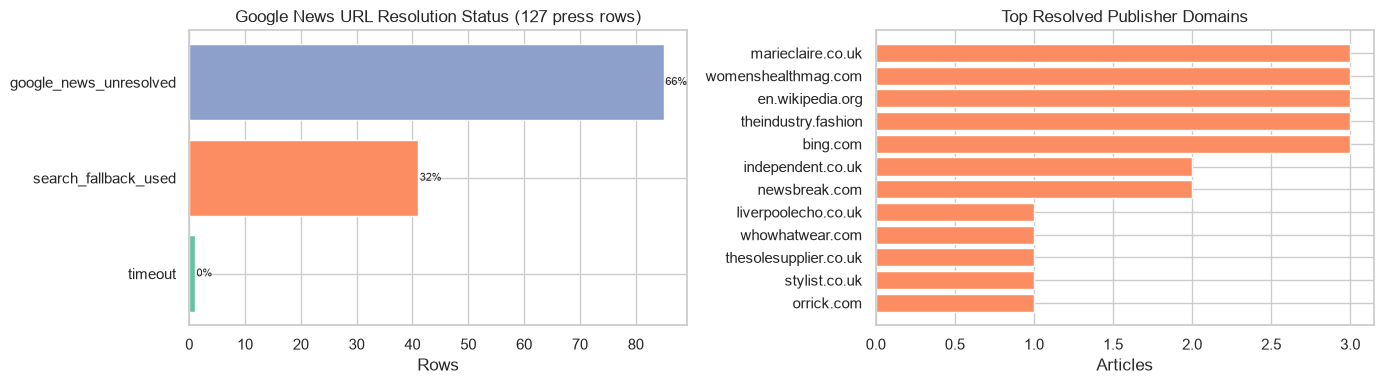


Unresolved URL queue (86 rows):
                brand                                                                                                                                title  url_resolution_status
                 TALA Want to Look Effortlessly Stylish Whilst Getting a Sweat On? 10 Cool Girl Activewear Brands You Need to Know About - Marie Claire UK google_news_unresolved
                 TALA                                              In Review 2025: The big openings, refurbs and pop-ups of the year - TheIndustry.fashion google_news_unresolved
                 TALA                                   We’re Notoriously Fussy Editors—Our Pick of the 21 Best Gym Leggings You Can Buy - Marie Claire UK google_news_unresolved
                 TALA                                                                                         CEO of Grace Beverley’s Tala exits - Drapers google_news_unresolved
                 TALA                                                        

In [19]:
# URL resolution status for press sources
if "press_reddit_sources" in dfs15:
    pr15 = dfs15["press_reddit_sources"]
    if "url_resolution_status" in pr15.columns:
        fig, axes = plt.subplots(1, 2, figsize=(14, 4))

        status_counts = pr15["url_resolution_status"].value_counts()
        axes[0].barh(status_counts.index[::-1], status_counts.values[::-1],
                     color=sns.color_palette("Set2", len(status_counts)))
        axes[0].set_title("Google News URL Resolution Status (127 press rows)")
        axes[0].set_xlabel("Rows")
        for i, (s, n) in enumerate(reversed(list(status_counts.items()))):
            axes[0].text(n + 0.3, i, f"{100*n//len(pr15)}%", va="center", fontsize=8)

        # Resolved domain distribution (top 12, excluding google)
        resolved = pr15[pr15["url_resolution_status"].isin(["resolved", "search_fallback_used"])]
        if not resolved.empty and "resolved_domain" in resolved.columns:
            top_domains = resolved["resolved_domain"].value_counts().head(12)
            axes[1].barh(top_domains.index[::-1], top_domains.values[::-1],
                         color=sns.color_palette("Set2")[1])
            axes[1].set_title("Top Resolved Publisher Domains")
            axes[1].set_xlabel("Articles")

        plt.tight_layout()
        plt.savefig(PROJECT_ROOT / "outputs" / "figures" / "day1_5_url_resolution.png",
                    dpi=150, bbox_inches="tight")
        plt.show()

        # Unresolved queue
        unresolved = pr15[~pr15["url_resolution_status"].isin(["resolved", "search_fallback_used"])]
        print(f"\nUnresolved URL queue ({len(unresolved)} rows):")
        if not unresolved.empty:
            print(unresolved[["brand", "title", "url_resolution_status"]].to_string(index=False))
            unresolved_path = PROJECT_ROOT / "outputs" / "tables" / "day1_5_unresolved_press_urls.csv"
            unresolved[["brand", "title", "source_url", "url_resolution_status"]].to_csv(
                unresolved_path, index=False)
            print(f"\nSaved: {unresolved_path}")
        else:
            print("All URLs resolved.")

---

## Day 2 — Evidence Hydration and Corpus Construction

Hydrated files live in `data/interim/day2/`. RAG corpora in `data/corpora/`.
Run `python scripts/hydrate_day2_sources.py` to (re)generate.

> **Input:** `data/interim/day1_5/*_patched.csv`
> **Output:** 3 RAG corpora + hydrated source files + quality-gate report

In [20]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="Set2")

DAY2_DIR  = PROJECT_ROOT / "data" / "interim" / "day2"
CORPUS_DIR = PROJECT_ROOT / "data" / "corpora"
T = PROJECT_ROOT / "outputs" / "tables"

# Load corpus files
corpora = {}
for name in ("official_claims_corpus", "customer_experience_corpus", "creator_strategy_corpus"):
    p = CORPUS_DIR / f"{name}.csv"
    if p.exists():
        corpora[name] = pd.read_csv(p)
        print(f"  [OK] {name}: {len(corpora[name])} records")
    else:
        print(f"  [MISSING] {name}")

# Load hydration summary
hydration_summary_path = T / "day2_hydration_summary.csv"
if hydration_summary_path.exists():
    hydration_summary = pd.read_csv(hydration_summary_path)
    display(hydration_summary.style.set_caption("Day 2 Hydration Summary"))
else:
    print("Run scripts/hydrate_day2_sources.py to generate this table.")

  [OK] official_claims_corpus: 37 records
  [OK] customer_experience_corpus: 95 records
  [OK] creator_strategy_corpus: 61 records


,source_type,attempted,hydrated_success,hydrated_failed,strong,medium,weak,unusable
0,press_reddit,127,123,4,34,5,84,4
1,official_claims,24,21,3,21,0,0,3
2,customer_reviews,56,22,34,16,2,3,35
3,competitor_platforms,37,32,5,25,6,1,5


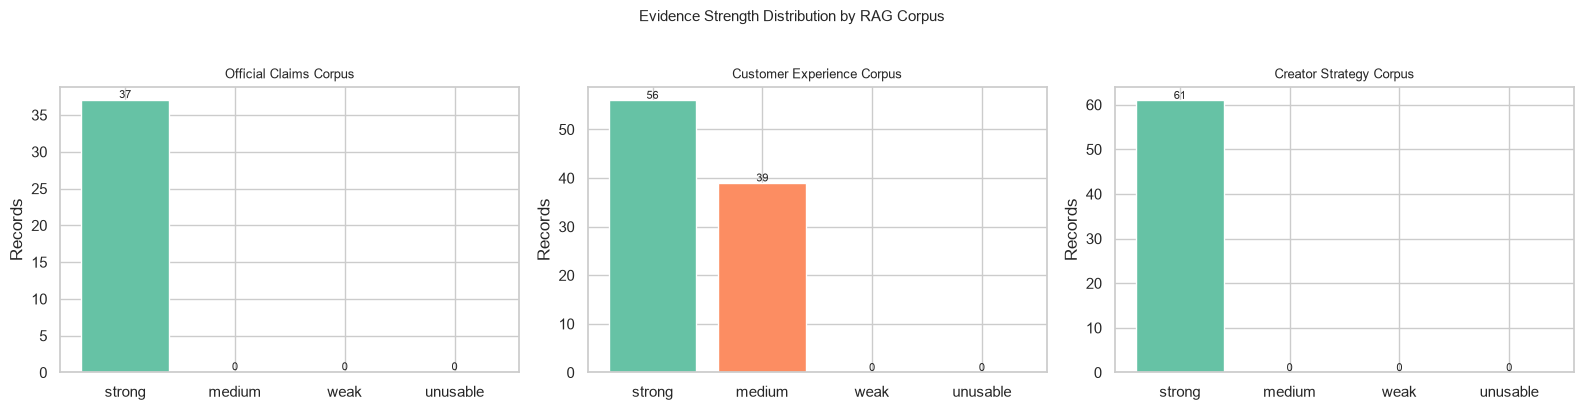

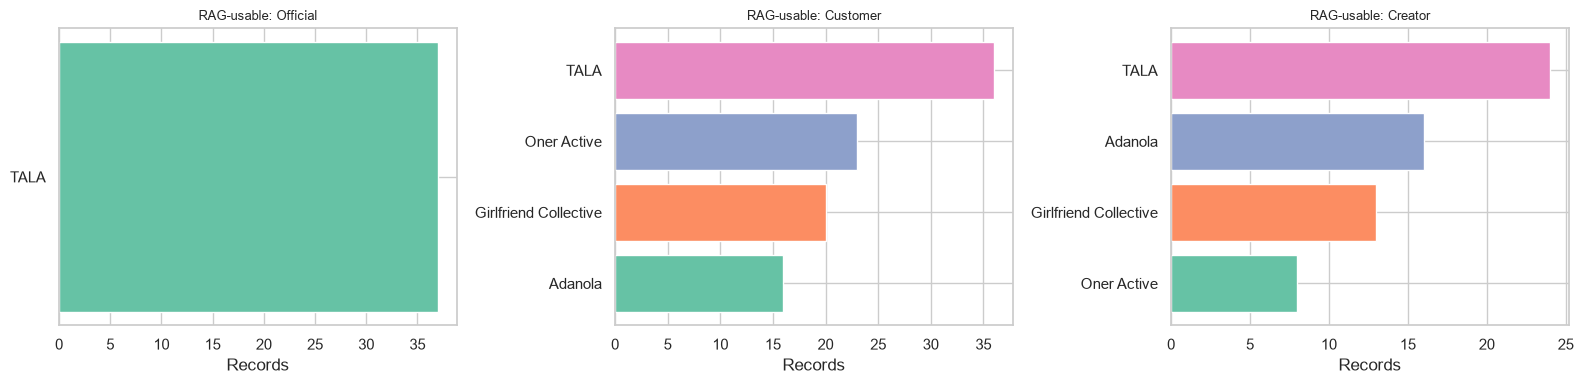

In [21]:
# Evidence-strength distribution across all corpora
if corpora:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    strength_order = ["strong", "medium", "weak", "unusable"]
    colors = sns.color_palette("Set2", 4)

    for ax, (name, df) in zip(axes, corpora.items()):
        if df.empty:
            continue
        counts = df["evidence_strength"].value_counts().reindex(strength_order, fill_value=0)
        ax.bar(counts.index, counts.values, color=colors)
        ax.set_title(name.replace("_", " ").title(), fontsize=9)
        ax.set_ylabel("Records")
        for i, v in enumerate(counts.values):
            ax.text(i, v + 0.3, str(v), ha="center", fontsize=8)

    plt.suptitle("Evidence Strength Distribution by RAG Corpus", fontsize=11, y=1.02)
    plt.tight_layout()
    plt.savefig(PROJECT_ROOT / "outputs" / "figures" / "day2_evidence_strength.png",
                dpi=150, bbox_inches="tight")
    plt.show()

# RAG-usable corpus coverage by brand
if corpora:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    for ax, (name, df) in zip(axes, corpora.items()):
        if df.empty or "brand" not in df.columns:
            continue
        rag = df[df["rag_usable"] == True]
        brand_counts = rag["brand"].value_counts()
        ax.barh(brand_counts.index[::-1], brand_counts.values[::-1],
                color=sns.color_palette("Set2", len(brand_counts)))
        ax.set_title(f"RAG-usable: {name.split('_')[0].title()}", fontsize=9)
        ax.set_xlabel("Records")
    plt.tight_layout()
    plt.savefig(PROJECT_ROOT / "outputs" / "figures" / "day2_rag_by_brand.png",
                dpi=150, bbox_inches="tight")
    plt.show()

---

## Day 2 Task 1B — Creator Evidence Repair

`creator_posts_enriched.csv` genuinely failed validation after the Day 2 schema fix
(blank `creator_handle`, 2 Instagram programme URLs mis-marked as posts, 9 rows
missing `evidence_strength`). `scripts/repair_day2_creator_evidence.py` repaired it:
strict URL classification, live creator-identity resolution (YouTube oEmbed / TikTok
URL parsing — no fabricated handles), brand-link verification from actual caption/title
text, and evidence-strength rules requiring a verified identity + verified brand link
before a post counts as usable. See `docs/day2_evidence_hydration_audit.md` §7 for the
full methodology and results.

creator_posts_enriched.csv: 65 rows (61 usable_as_creator_post=True)

Invalidation reasons (non-usable rows):
invalidation_reason
instagram_programme_or_campaign_page    2
creator_identity_unresolved             2

Creator identity source (usable rows only):
creator_identity_source
youtube_oembed    60
tiktok_url         1


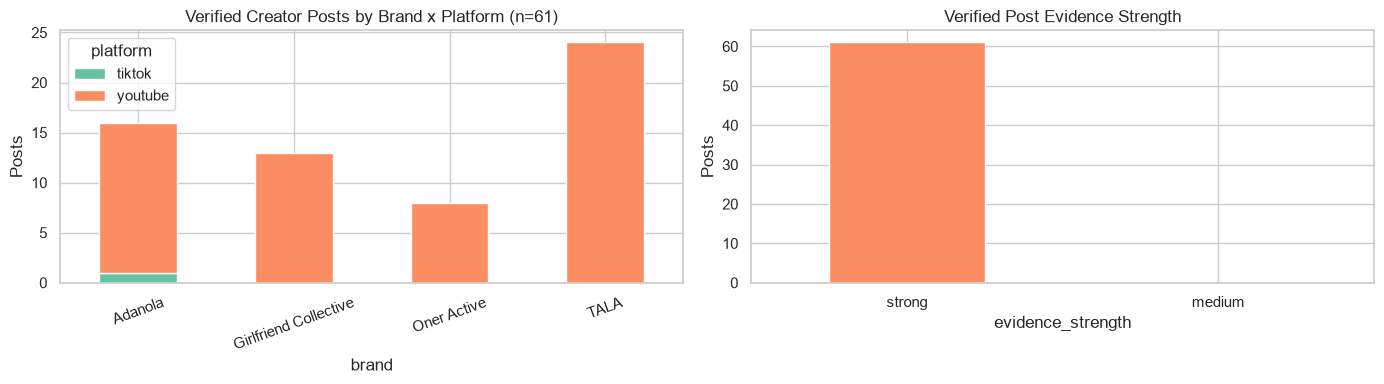


Day 2 quality gates (post-repair):


,gate,threshold,actual,status
0,official_claims_strong,15,37,PASS
1,customer_experience_strong_medium,25,95,PASS
2,creator_strategy_verified_strong_medium,20,61,PASS
3,total_rag_usable,60,193,PASS
4,brands_in_creator_evidence,3,4,PASS
5,no_search_url_as_creator_post,0,0,PASS
6,no_weak_record_as_rag_usable,0,0,PASS



Overall: GO


In [22]:
creators_enriched_path = DAY2_DIR / "creator_posts_enriched.csv"
gate_report_path = T / "day2_quality_gate_report.csv"

if creators_enriched_path.exists():
    creators_repaired = pd.read_csv(creators_enriched_path)
    verified = creators_repaired[creators_repaired["usable_as_creator_post"] == True]

    print(f"creator_posts_enriched.csv: {len(creators_repaired)} rows "
          f"({len(verified)} usable_as_creator_post=True)")
    print()
    print("Invalidation reasons (non-usable rows):")
    invalid = creators_repaired[creators_repaired["usable_as_creator_post"] != True]
    print(invalid["invalidation_reason"].value_counts().to_string())
    print()
    print("Creator identity source (usable rows only):")
    print(verified["creator_identity_source"].value_counts().to_string())

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    verified.groupby(["brand", "platform"]).size().unstack(fill_value=0).plot(
        kind="bar", stacked=True, ax=axes[0], color=sns.color_palette("Set2", 4))
    axes[0].set_title(f"Verified Creator Posts by Brand x Platform (n={len(verified)})")
    axes[0].set_ylabel("Posts")
    axes[0].tick_params(axis="x", rotation=20)

    verified["evidence_strength"].value_counts().reindex(
        ["strong", "medium"], fill_value=0
    ).plot(kind="bar", ax=axes[1], color=sns.color_palette("Set2")[1])
    axes[1].set_title("Verified Post Evidence Strength")
    axes[1].set_ylabel("Posts")
    axes[1].tick_params(axis="x", rotation=0)

    plt.tight_layout()
    plt.savefig(PROJECT_ROOT / "outputs" / "figures" / "day2_creator_repair_summary.png",
                dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("Run scripts/repair_day2_creator_evidence.py first.")

if gate_report_path.exists():
    gates = pd.read_csv(gate_report_path)
    print("\nDay 2 quality gates (post-repair):")
    display(gates[["gate", "threshold", "actual", "status"]])
    print(f"\nOverall: {gates['overall'].iloc[0]}")
